# ============================================================
# Loan Default Prediction - LendingClub Dataset (2007-2010)
# Goal: Predict whether a borrower will default on their loan
# Primary Metric: ROC-AUC (not accuracy - reasons explained ahead)
# ============================================================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
%matplotlib inline
sns.set_style('whitegrid')

In [8]:
df=pd.read_csv('loan_data.csv')
print(df.shape)
df.head

(9578, 14)


<bound method NDFrame.head of       credit.policy             purpose  int.rate  installment  \
0                 1  debt_consolidation    0.1189       829.10   
1                 1         credit_card    0.1071       228.22   
2                 1  debt_consolidation    0.1357       366.86   
3                 1  debt_consolidation    0.1008       162.34   
4                 1         credit_card    0.1426       102.92   
...             ...                 ...       ...          ...   
9573              0           all_other    0.1461       344.76   
9574              0           all_other    0.1253       257.70   
9575              0  debt_consolidation    0.1071        97.81   
9576              0    home_improvement    0.1600       351.58   
9577              0  debt_consolidation    0.1392       853.43   

      log.annual.inc    dti  fico  days.with.cr.line  revol.bal  revol.util  \
0          11.350407  19.48   737        5639.958333      28854        52.1   
1          11.08214

In [14]:
print("class distribution")
print(df['not.fully.paid'].value_counts())
print('/nPercentage:')
print(df['not.fully.paid'].value_counts(normalize=True) * 100)

class distribution
not.fully.paid
0    8045
1    1533
Name: count, dtype: int64
/nPercentage:
not.fully.paid
0    83.994571
1    16.005429
Name: proportion, dtype: float64


84% fully paid, 16% defaulted. This is the problem because of which accuracy is a bad metrics because even if model predicts everything as 0 , then alos it would give 84% accuracy. So we will use ROC-AUC.

In [17]:
print(df.info())
print('/n')
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB
None
/n
credit.policy        0
purpose              0
int.rate 

# Note: This dataset has no missing values as it was pre-processed 
# by LendingClub before public release. In production, we would 
# handle missing FICO scores via median imputation and missing 
# income values via model-based imputation given their importance 
# as features.

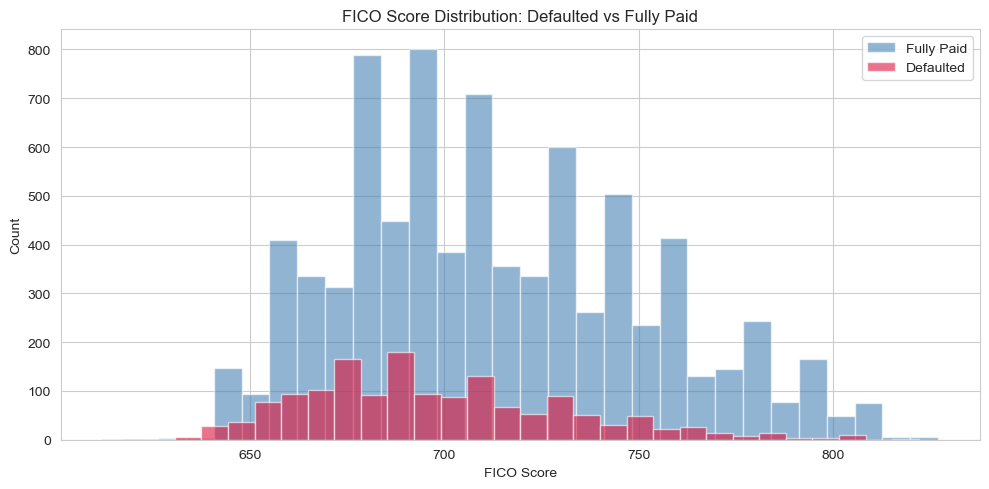

Avg FICO - Fully Paid: 713.3
Avg FICO - Defaulted: 697.8


In [20]:
# ============================================================
# EDA - Section 1: FICO Score vs Default Rate
# Higher FICO = better credit. Do defaulters actually have lower FICO?
# ============================================================

plt.figure(figsize=(10,5))
df[df['not.fully.paid']==0]['fico'].hist(bins=30, alpha=0.6, 
                                          color='steelblue', 
                                          label='Fully Paid')
df[df['not.fully.paid']==1]['fico'].hist(bins=30, alpha=0.6, 
                                          color='crimson', 
                                          label='Defaulted')
plt.xlabel('FICO Score')
plt.ylabel('Count')
plt.title('FICO Score Distribution: Defaulted vs Fully Paid')
plt.legend()
plt.tight_layout()
plt.show()

# Actual numbers
print("Avg FICO - Fully Paid:", round(df[df['not.fully.paid']==0]['fico'].mean(),1))
print("Avg FICO - Defaulted:", round(df[df['not.fully.paid']==1]['fico'].mean(),1))

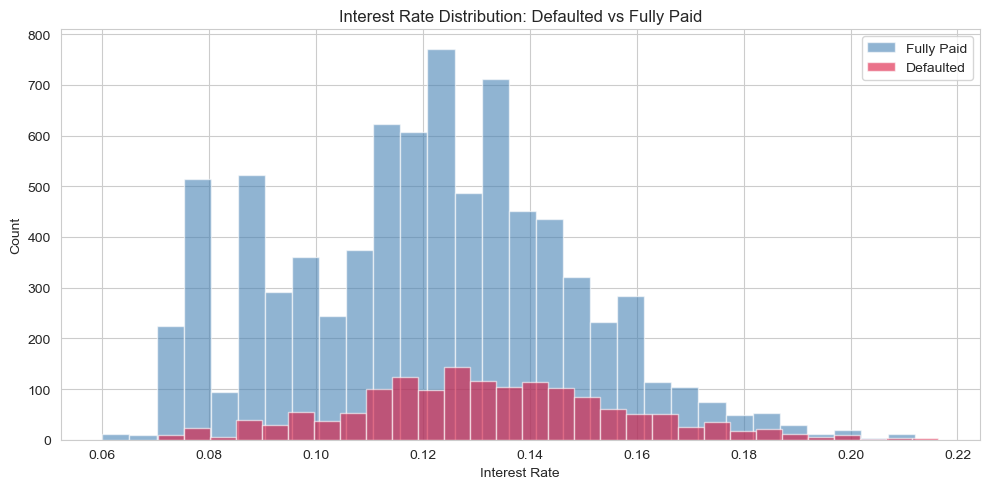

Avg Interest Rate - Fully Paid: 12.08 %
Avg Interest Rate - Defaulted: 13.25 %


In [22]:
# ============================================================
# EDA - Section 2: Interest Rate vs Default
# Riskier borrowers get higher rates - but does higher rate = more default?
# ============================================================

plt.figure(figsize=(10,5))
df[df['not.fully.paid']==0]['int.rate'].hist(bins=30, alpha=0.6,
                                              color='steelblue',
                                              label='Fully Paid')
df[df['not.fully.paid']==1]['int.rate'].hist(bins=30, alpha=0.6,
                                              color='crimson',
                                              label='Defaulted')
plt.xlabel('Interest Rate')
plt.ylabel('Count')
plt.title('Interest Rate Distribution: Defaulted vs Fully Paid')
plt.legend()
plt.tight_layout()
plt.show()

print("Avg Interest Rate - Fully Paid:", 
      round(df[df['not.fully.paid']==0]['int.rate'].mean()*100, 2), "%")
print("Avg Interest Rate - Defaulted:", 
      round(df[df['not.fully.paid']==1]['int.rate'].mean()*100, 2), "%")

                    default_rate  total_loans
purpose                                      
small_business         27.786753          619
educational            20.116618          343
home_improvement       17.011129          629
all_other              16.602317         2331
debt_consolidation     15.238817         3957
credit_card            11.568938         1262
major_purchase         11.212815          437


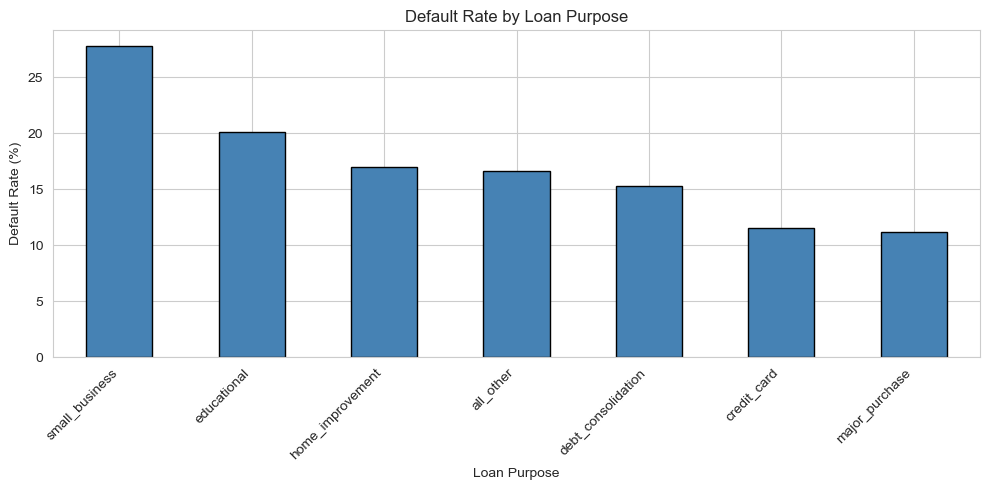

In [24]:
# ============================================================
# EDA - Section 3: Loan Purpose vs Default Rate
# Which loan purposes have highest default rates?
# ============================================================

purpose_default = df.groupby('purpose')['not.fully.paid'].agg(['mean', 'count'])
purpose_default.columns = ['default_rate', 'total_loans']
purpose_default['default_rate'] = purpose_default['default_rate'] * 100
purpose_default = purpose_default.sort_values('default_rate', ascending=False)

print(purpose_default)

plt.figure(figsize=(10,5))
purpose_default['default_rate'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Default Rate by Loan Purpose')
plt.xlabel('Loan Purpose')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

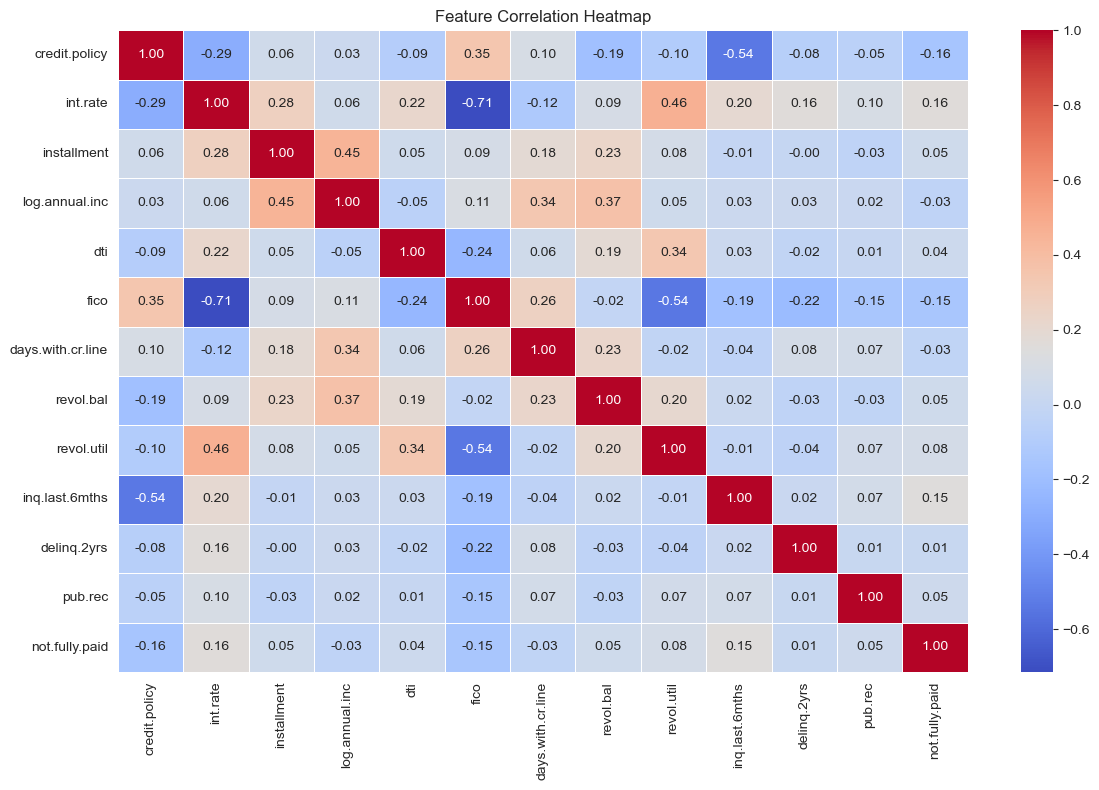


Correlation with default (not.fully.paid):
not.fully.paid       1.000000
int.rate             0.159552
inq.last.6mths       0.149452
revol.util           0.082088
revol.bal            0.053699
installment          0.049955
pub.rec              0.048634
dti                  0.037362
delinq.2yrs          0.008881
days.with.cr.line   -0.029237
log.annual.inc      -0.033439
fico                -0.149666
credit.policy       -0.158119
Name: not.fully.paid, dtype: float64


In [26]:
# ============================================================
# EDA - Section 4: Correlation Heatmap
# Which numerical features are most correlated with default?
# ============================================================

plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Most correlated features with target
print("\nCorrelation with default (not.fully.paid):")
print(corr['not.fully.paid'].sort_values(ascending=False))

In [28]:
# ============================================================
# PREPROCESSING
# ============================================================

# Step 1: One-hot encode 'purpose' column
df_model = pd.get_dummies(df, columns=['purpose'], drop_first=True)

# Step 2: Define features and target
X = df_model.drop('not.fully.paid', axis=1)
y = df_model['not.fully.paid']

# Step 3: Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True) * 100)
print("\nClass distribution in test set:")
print(y_test.value_counts(normalize=True) * 100)

Training set size: (6704, 18)
Test set size: (2874, 18)

Class distribution in training set:
not.fully.paid
0    83.99463
1    16.00537
Name: proportion, dtype: float64

Class distribution in test set:
not.fully.paid
0    83.994433
1    16.005567
Name: proportion, dtype: float64


In [30]:
# ============================================================
# BASELINE MODEL - Decision Tree
# Why baseline? To show how bad a single tree performs
# before we move to Random Forest
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                              roc_auc_score)

# Train
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predict
dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:,1]

# Evaluate
print("=" * 50)
print("DECISION TREE - BASELINE RESULTS")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_test, dt_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, dt_pred))
print("\nROC-AUC Score:", round(roc_auc_score(y_test, dt_prob), 4))

DECISION TREE - BASELINE RESULTS

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      2414
           1       0.21      0.22      0.21       460

    accuracy                           0.75      2874
   macro avg       0.53      0.53      0.53      2874
weighted avg       0.75      0.75      0.75      2874

Confusion Matrix:
[[2052  362]
 [ 361   99]]

ROC-AUC Score: 0.5326


In [32]:
# ============================================================
# RANDOM FOREST - Vanilla (no imbalance handling yet)
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# Train
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predict
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

# Evaluate
print("=" * 50)
print("RANDOM FOREST - VANILLA RESULTS")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
print("\nROC-AUC Score:", round(roc_auc_score(y_test, rf_prob), 4))

RANDOM FOREST - VANILLA RESULTS

Classification Report:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      2414
           1       0.37      0.02      0.03       460

    accuracy                           0.84      2874
   macro avg       0.60      0.51      0.47      2874
weighted avg       0.77      0.84      0.77      2874

Confusion Matrix:
[[2402   12]
 [ 453    7]]

ROC-AUC Score: 0.6542


In [34]:
# ============================================================
# RANDOM FOREST - class_weight='balanced'
# Tells the model to penalize mistakes on minority class more
# ============================================================

rf_balanced = RandomForestClassifier(n_estimators=100, 
                                      class_weight='balanced',
                                      random_state=42, 
                                      n_jobs=-1)
rf_balanced.fit(X_train, y_train)

rf_bal_pred = rf_balanced.predict(X_test)
rf_bal_prob = rf_balanced.predict_proba(X_test)[:,1]

print("=" * 50)
print("RANDOM FOREST - BALANCED CLASS WEIGHT")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_test, rf_bal_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_bal_pred))
print("\nROC-AUC Score:", round(roc_auc_score(y_test, rf_bal_prob), 4))

RANDOM FOREST - BALANCED CLASS WEIGHT

Classification Report:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      2414
           1       0.57      0.02      0.03       460

    accuracy                           0.84      2874
   macro avg       0.71      0.51      0.47      2874
weighted avg       0.80      0.84      0.77      2874

Confusion Matrix:
[[2408    6]
 [ 452    8]]

ROC-AUC Score: 0.6613


In [36]:
# ============================================================
# RANDOM FOREST - SMOTE (Synthetic Minority Oversampling)
# Creates synthetic examples of minority class in training data
# ============================================================

from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_resampled.value_counts().to_dict())

rf_smote = RandomForestClassifier(n_estimators=100, 
                                   random_state=42, 
                                   n_jobs=-1)
rf_smote.fit(X_resampled, y_resampled)

rf_smote_pred = rf_smote.predict(X_test)
rf_smote_prob = rf_smote.predict_proba(X_test)[:,1]

print("\n" + "=" * 50)
print("RANDOM FOREST - SMOTE")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_test, rf_smote_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_smote_pred))
print("\nROC-AUC Score:", round(roc_auc_score(y_test, rf_smote_prob), 4))

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Before SMOTE: {0: 5631, 1: 1073}
After SMOTE: {0: 5631, 1: 5631}

RANDOM FOREST - SMOTE

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      2414
           1       0.27      0.23      0.25       460

    accuracy                           0.77      2874
   macro avg       0.56      0.55      0.56      2874
weighted avg       0.76      0.77      0.77      2874

Confusion Matrix:
[[2121  293]
 [ 354  106]]

ROC-AUC Score: 0.6451


In [38]:
# ============================================================
# MODEL COMPARISON SUMMARY
# ============================================================

results = {
    'Model': ['Decision Tree', 'RF Vanilla', 'RF Balanced', 'RF SMOTE'],
    'ROC-AUC': [
        round(roc_auc_score(y_test, dt_prob), 4),
        round(roc_auc_score(y_test, rf_prob), 4),
        round(roc_auc_score(y_test, rf_bal_prob), 4),
        round(roc_auc_score(y_test, rf_smote_prob), 4)
    ],
    'Default Recall': [0.22, 0.02, 0.02, 0.23],
    'Default Precision': [0.21, 0.37, 0.57, 0.27],
    'Accuracy': [0.75, 0.84, 0.84, 0.77]
}

import pandas as pd
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Best ROC-AUC model
best = results_df.loc[results_df['ROC-AUC'].idxmax()]
print(f"\nBest ROC-AUC: {best['Model']} ({best['ROC-AUC']})")

        Model  ROC-AUC  Default Recall  Default Precision  Accuracy
Decision Tree   0.5326            0.22               0.21      0.75
   RF Vanilla   0.6542            0.02               0.37      0.84
  RF Balanced   0.6613            0.02               0.57      0.84
     RF SMOTE   0.6451            0.23               0.27      0.77

Best ROC-AUC: RF Balanced (0.6613)


Avg estimated loan value: $11487.22
Avg interest income lost (FP): $1378.47

Optimal Threshold: 0.14
Minimum Business Cost: $2,948,079.85


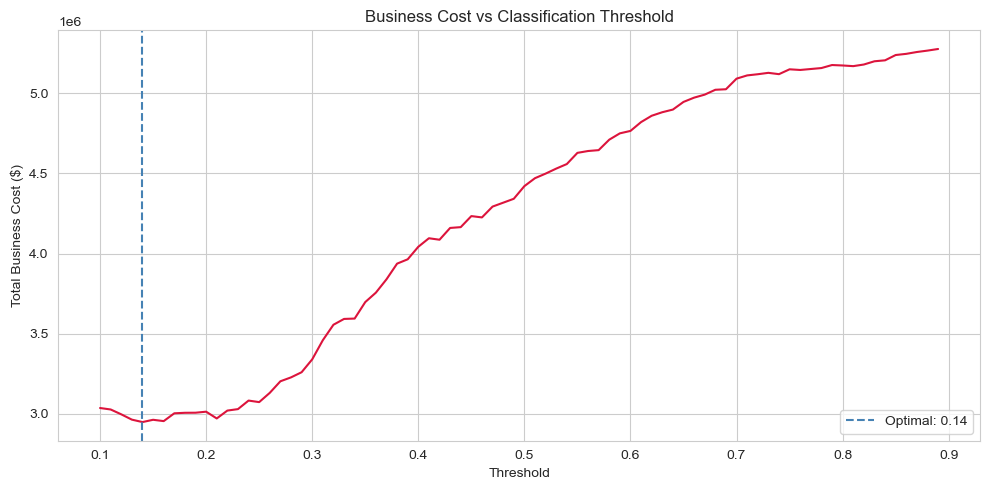

In [40]:
# ============================================================
# THRESHOLD OPTIMIZATION - Business Cost Framework
# FN cost = average loan amount lost
# FP cost = average interest income lost
# ============================================================

from sklearn.metrics import roc_curve
import numpy as np

# Average loan values from data
avg_loan = df['installment'].mean() * 36  # approx loan principal
avg_interest_loss = avg_loan * 0.12       # ~12% interest income

print(f"Avg estimated loan value: ${avg_loan:.2f}")
print(f"Avg interest income lost (FP): ${avg_interest_loss:.2f}")

# Use RF SMOTE probabilities (best recall)
thresholds = np.arange(0.1, 0.9, 0.01)
costs = []

for thresh in thresholds:
    preds = (rf_smote_prob >= thresh).astype(int)
    tn = ((preds == 0) & (y_test == 0)).sum()
    fp = ((preds == 1) & (y_test == 0)).sum()
    fn = ((preds == 0) & (y_test == 1)).sum()
    tp = ((preds == 1) & (y_test == 1)).sum()
    
    total_cost = (fn * avg_loan) + (fp * avg_interest_loss)
    costs.append(total_cost)

optimal_threshold = thresholds[np.argmin(costs)]
print(f"\nOptimal Threshold: {optimal_threshold:.2f}")
print(f"Minimum Business Cost: ${min(costs):,.2f}")

plt.figure(figsize=(10,5))
plt.plot(thresholds, costs, color='crimson')
plt.axvline(optimal_threshold, color='steelblue', 
            linestyle='--', label=f'Optimal: {optimal_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Total Business Cost ($)')
plt.title('Business Cost vs Classification Threshold')
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
# ============================================================
# FINAL MODEL - RF SMOTE with Optimal Threshold (0.14)
# ============================================================

final_preds = (rf_smote_prob >= optimal_threshold).astype(int)

print("=" * 50)
print(f"FINAL MODEL - THRESHOLD: {optimal_threshold:.2f}")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_test, final_preds))
print("Confusion Matrix:")
print(confusion_matrix(y_test, final_preds))
print("\nROC-AUC Score:", round(roc_auc_score(y_test, rf_smote_prob), 4))

# Compare default 0.5 vs optimal threshold
tn_old = ((rf_smote_pred == 0) & (y_test == 0)).sum()
fn_old = ((rf_smote_pred == 0) & (y_test == 1)).sum()
fp_old = ((rf_smote_pred == 1) & (y_test == 0)).sum()
tp_old = ((rf_smote_pred == 1) & (y_test == 1)).sum()

tn_new = ((final_preds == 0) & (y_test == 0)).sum()
fn_new = ((final_preds == 0) & (y_test == 1)).sum()
fp_new = ((final_preds == 1) & (y_test == 0)).sum()
tp_new = ((final_preds == 1) & (y_test == 1)).sum()

cost_old = (fn_old * avg_loan) + (fp_old * avg_interest_loss)
cost_new = (fn_new * avg_loan) + (fp_new * avg_interest_loss)

print(f"\nBusiness Cost at threshold 0.50: ${cost_old:,.2f}")
print(f"Business Cost at threshold {optimal_threshold:.2f}: ${cost_new:,.2f}")
print(f"Cost Saved: ${cost_old - cost_new:,.2f}")
print(f"\nDefaulters caught at 0.50: {tp_old}/460")
print(f"Defaulters caught at {optimal_threshold:.2f}: {tp_new}/460")

FINAL MODEL - THRESHOLD: 0.14

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.20      0.34      2414
           1       0.18      0.94      0.31       460

    accuracy                           0.32      2874
   macro avg       0.57      0.57      0.32      2874
weighted avg       0.83      0.32      0.33      2874

Confusion Matrix:
[[ 492 1922]
 [  26  434]]

ROC-AUC Score: 0.6451

Business Cost at threshold 0.50: $4,470,366.10
Business Cost at threshold 0.14: $2,948,079.85
Cost Saved: $1,522,286.25

Defaulters caught at 0.50: 106/460
Defaulters caught at 0.14: 434/460


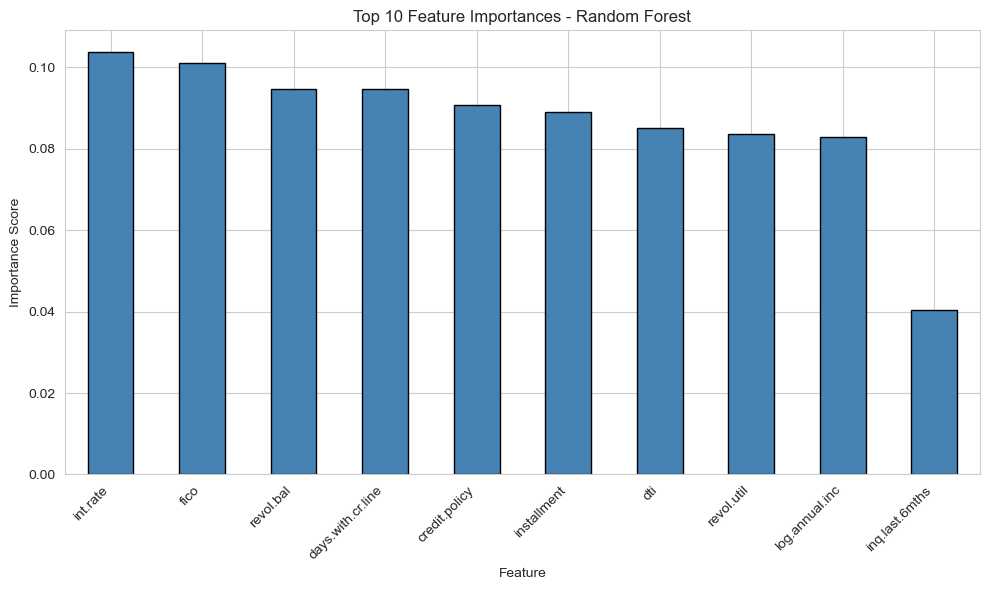


Top 10 Features:
int.rate             0.103873
fico                 0.100957
revol.bal            0.094706
days.with.cr.line    0.094610
credit.policy        0.090725
installment          0.088987
dti                  0.085180
revol.util           0.083507
log.annual.inc       0.082812
inq.last.6mths       0.040314
dtype: float64


In [44]:
# ============================================================
# FEATURE IMPORTANCE - Which features drive default prediction?
# ============================================================

feat_imp = pd.Series(rf_smote.feature_importances_, 
                      index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.head(10).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
print(feat_imp.head(10))

In [46]:
# ============================================================
# SAVE MODEL FOR DEPLOYMENT
# ============================================================

import joblib

# Save model and threshold
joblib.dump(rf_smote, 'model.pkl')
joblib.dump(optimal_threshold, 'threshold.pkl')

print("Model saved as model.pkl")
print("Threshold saved as threshold.pkl")
print(f"Optimal threshold: {optimal_threshold:.2f}")

Model saved as model.pkl
Threshold saved as threshold.pkl
Optimal threshold: 0.14
